In [109]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import requests 
import io 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 

In [110]:
NHANES_BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles"

urls = {
    "demo": f"{NHANES_BASE}/DEMO_J.XPT",
    "bmx":  f"{NHANES_BASE}/BMX_J.XPT",
    "dr1":  f"{NHANES_BASE}/DR1TOT_J.XPT",
    "dr2":  f"{NHANES_BASE}/DR2TOT_J.XPT", 
    "paq":  f"{NHANES_BASE}/PAQ_J.XPT",
    "slq":  f"{NHANES_BASE}/SLQ_J.XPT"   
}


In [111]:
def load_nhanes(name, url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=30)
    if response.status_code != 200:
        raise Exception(f"Failed to fetch {name}")
    if b"<html" in response.content[:100].lower():
        raise Exception(f"{name} returned HTML - URL is wrong or file moved")
    return pd.read_sas(io.BytesIO(response.content), format='xport', encoding='utf-8')

In [112]:
demo_data = load_nhanes("demo", urls["demo"])
bmx_data = load_nhanes("bmx", urls["bmx"])
diet1_data = load_nhanes("dr1", urls["dr1"])
diet2_data = load_nhanes("dr2", urls["dr2"])

In [113]:
demo_data.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC',
       'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL',
       'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY',
       'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ',
       'DMDFMSIZ', 'DMDHHSZA', 'DMDHHSZB', 'DMDHHSZE', 'DMDHRGND', 'DMDHRAGZ',
       'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU',
       'SDMVSTRA', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR'],
      dtype='str')

In [114]:
demo_data = demo_data[["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"]]
bmx_data = bmx_data[["SEQN", "BMXWT", "BMXHT", "BMXWAIST", "BMXHIP", "BMXARML"] ]

In [115]:
metabolic_df = pd.merge(demo_data, bmx_data, on="SEQN", how="inner")

In [116]:
metabolic_df.isnull().sum()

SEQN           0
RIDAGEYR       0
RIAGENDR       0
RIDRETH3       0
BMXWT        124
BMXHT        688
BMXWAIST    1103
BMXHIP      2665
BMXARML      527
dtype: int64

In [117]:
metabolic_df = metabolic_df.dropna(subset=["BMXWT"])
metabolic_df["BMXHT"] = metabolic_df.groupby(["RIDAGEYR", "RIAGENDR"])["BMXHT"].transform(lambda x: x.fillna(x.median()))
metabolic_df = metabolic_df.dropna(subset=["BMXHT"])

In [118]:
corr_cols = ["RIDAGEYR", "RIDAGEYR", "RIDRETH3", "BMXHT", "BMXWAIST", "BMXHIP", "BMXARML"]

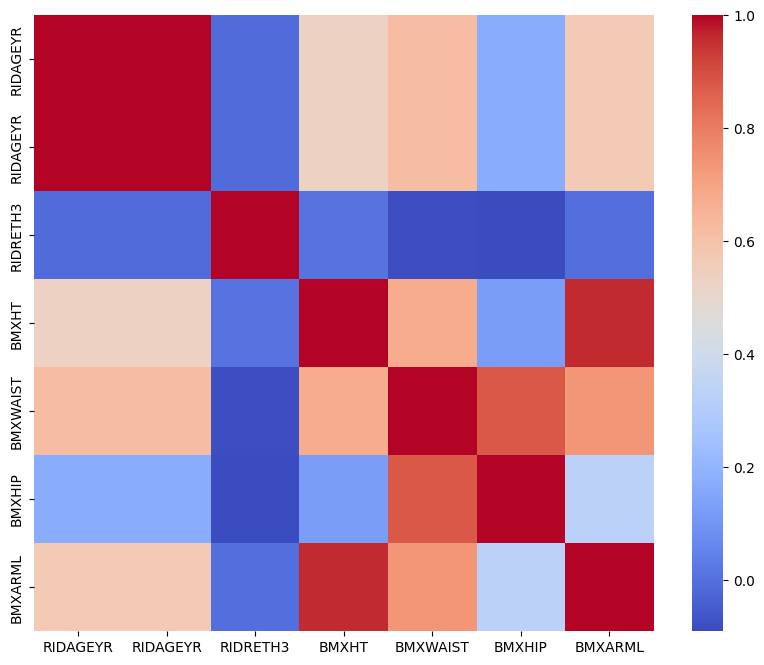

In [119]:
correlation_matrix = metabolic_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.show()

In [120]:
target = metabolic_df["BMXWT"]
X = metabolic_df.drop(["SEQN", "BMXWT"], axis=1)

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)

In [122]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [123]:
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
forest_importances = pd.Series(result.importances_mean, index=X_test.columns)
top_features = forest_importances[forest_importances > 0].sort_values(ascending=False)

print("Real Important Features:")
top_features.head(10)

Real Important Features:


BMXWAIST    0.315427
BMXHIP      0.166246
BMXHT       0.151255
RIDAGEYR    0.102509
RIAGENDR    0.008136
dtype: float64

In [124]:
cols1 = ["SEQN", "DR1TKCAL", "DR1TPROT", "DR1TTFAT", "DR1TCARB", "DR1TSUGR", "DR1TFIBE"]
cols2 = ["SEQN", "DR2TKCAL", "DR2TPROT", "DR2TTFAT", "DR2TCARB", "DR2TSUGR", "DR2TFIBE"]
dietary = diet1_data[cols1].merge(diet2_data[cols2], on="SEQN", how="left")

dietary["calories"] = dietary[["DR1TKCAL", "DR2TKCAL"]].mean(axis=1)
dietary["protein_g"] = dietary[["DR1TPROT", "DR2TPROT"]].mean(axis=1)
dietary["fat_g"]     = dietary[["DR1TTFAT", "DR2TTFAT"]].mean(axis=1)
dietary["carb_g"]    = dietary[["DR1TCARB", "DR2TCARB"]].mean(axis=1)
dietary["sugar_g"]     = dietary[["DR1TSUGR", "DR2TSUGR"]].mean(axis=1)
dietary["fiber_g"]    = dietary[["DR1TFIBE", "DR1TFIBE"]].mean(axis=1)

dietary["calories"] = (dietary["DR1TKCAL"] + dietary["DR2TKCAL"]) / 2
dietary["protein_g"] = (dietary["DR1TPROT"] + dietary["DR2TPROT"]) / 2
dietary["fat_g"] = (dietary["DR1TTFAT"] + dietary["DR2TTFAT"]) / 2
dietary["carb_g"] = (dietary["DR1TCARB"] + dietary["DR2TCARB"]) / 2
dietary["sugar_g"]  = (dietary["DR1TSUGR"] + dietary["DR2TSUGR"]) / 2
dietary["fiber_g"]  = (dietary["DR1TFIBE"] + dietary["DR2TFIBE"]) / 2

In [125]:
nutrients = ["calories", "protein_g", "fat_g", "carb_g", "sugar_g", "fiber_g"]
dietary = dietary[["SEQN", "calories", "protein_g", "fat_g", "carb_g", "sugar_g", "fiber_g"]]
dietary.dropna(subset=nutrients, inplace=True)

In [126]:
final_df = metabolic_df.merge(dietary, on="SEQN", how="inner")

In [127]:
final_df['tdee'] = (10 * final_df['BMXWT']) + (6.25 * final_df['BMXHT']) - (5 * final_df['RIDAGEYR'])
final_df.loc[final_df['RIAGENDR'] == 1, 'tdee'] += 5
final_df.loc[final_df['RIAGENDR'] == 2, 'tdee'] -= 161
final_df['tdee'] *= 1.2

In [128]:
final_df["sur_def"] = final_df["calories"] - final_df["tdee"]

In [129]:
len(final_df[final_df['sur_def'] >  0])

3704

In [130]:
final_df.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXWT', 'BMXHT',
       'BMXWAIST', 'BMXHIP', 'BMXARML', 'calories', 'protein_g', 'fat_g',
       'carb_g', 'sugar_g', 'fiber_g', 'tdee', 'sur_def'],
      dtype='str')

In [131]:
target = final_df['BMXWT']
num_cols = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXHT',
       'BMXWAIST', 'BMXHIP', 'BMXARML', 'calories', 'protein_g', 'fat_g',
       'carb_g', 'sugar_g', 'fiber_g', 'tdee', 'sur_def']
X = final_df[num_cols]

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)
X_train

,RIDAGEYR,RIAGENDR,RIDRETH3,BMXHT,BMXWAIST,BMXHIP,BMXARML,calories,protein_g,fat_g,carb_g,sugar_g,fiber_g,tdee,sur_def
1780,20.0,2.0,1.0,149.5,71.2,80.8,34.0,2582.5,131.765,92.445,313.810,117.540,20.10,1277.25,1305.25
2857,80.0,1.0,7.0,180.5,117.7,109.6,40.2,1434.5,64.870,66.050,154.725,35.905,18.95,2010.15,-575.65
5718,18.0,1.0,6.0,164.5,91.5,94.5,36.0,1597.5,95.055,57.860,173.025,68.275,8.75,1987.35,-389.85
5688,62.0,2.0,4.0,163.5,92.7,101.6,38.5,1049.5,23.055,34.790,165.405,80.320,10.95,1557.45,-507.95
4545,17.0,1.0,1.0,174.8,99.9,106.3,40.5,1680.5,64.455,74.345,191.885,80.765,12.30,2357.40,-676.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,36.0,1.0,1.0,175.9,115.7,110.2,38.2,4213.5,166.160,185.525,449.275,131.275,42.45,2490.45,1723.05
5191,51.0,1.0,2.0,172.9,110.6,115.3,36.7,1823.0,93.480,79.620,136.040,72.465,8.60,2143.95,-320.95
5226,55.0,2.0,6.0,166.8,77.4,99.0,34.0,2552.0,82.720,140.305,250.945,83.815,30.95,1433.40,1118.60
5390,15.0,1.0,4.0,177.2,73.6,91.5,36.6,1707.5,53.870,91.910,168.955,70.170,6.85,1984.20,-276.70


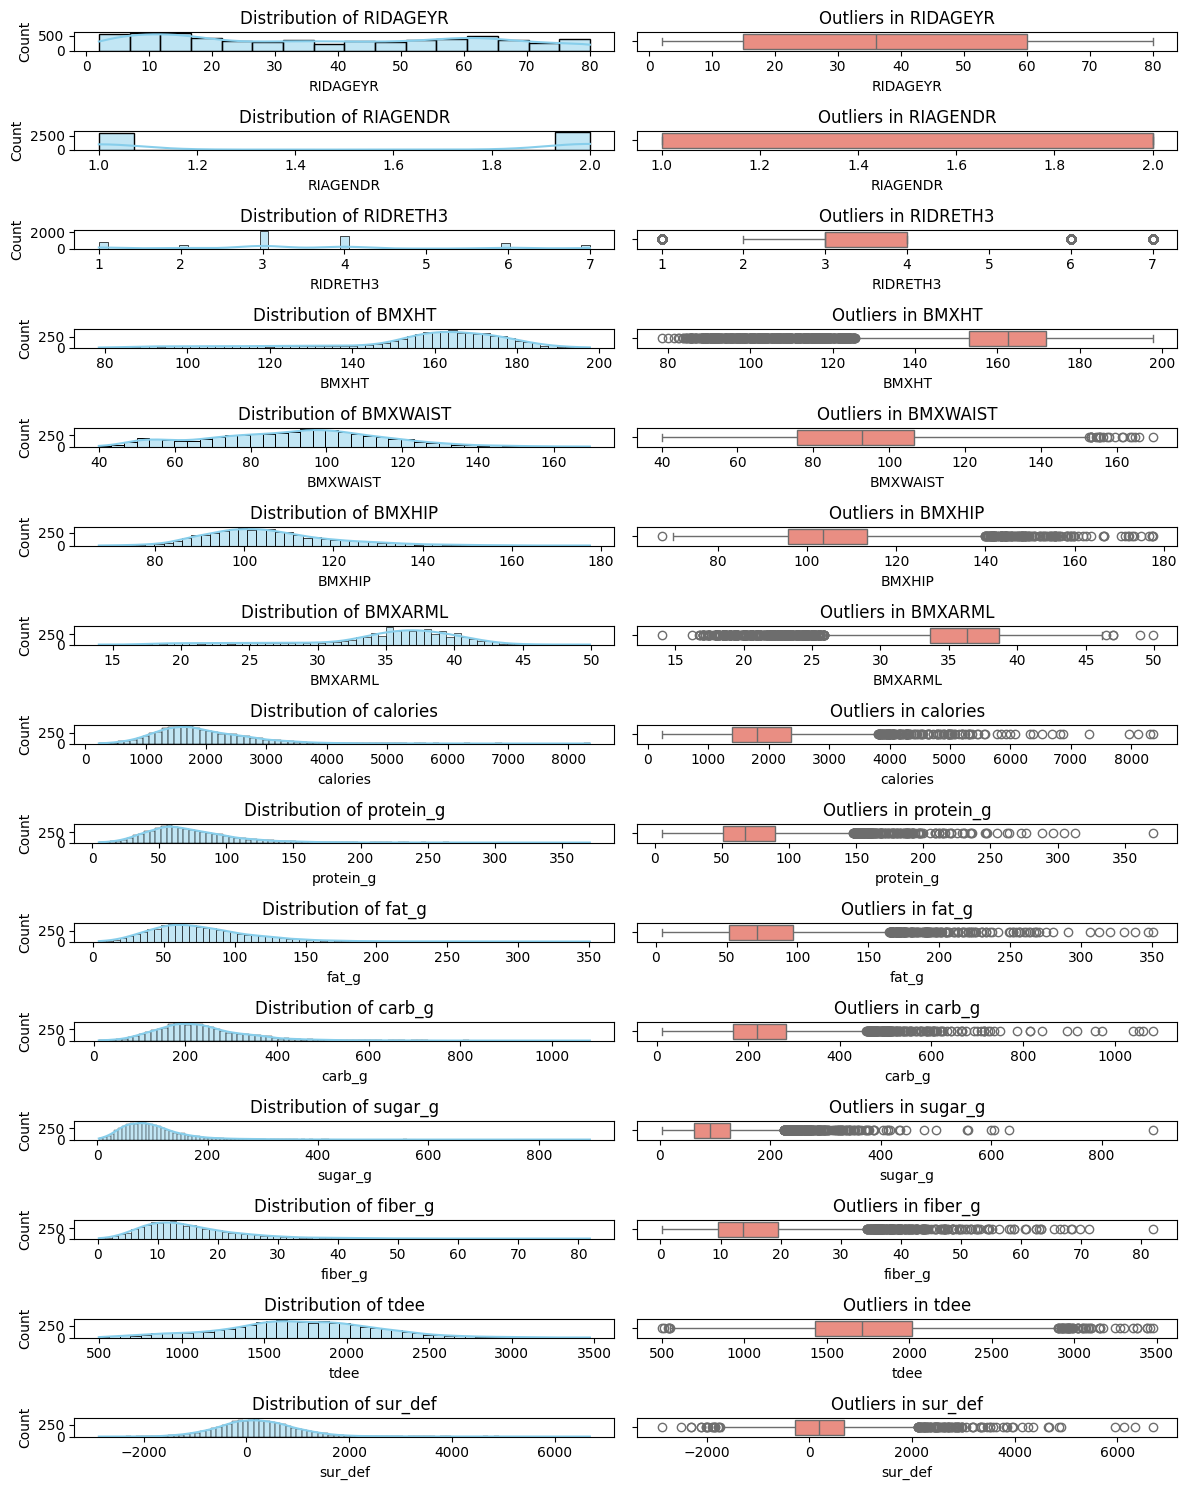

In [133]:
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(X[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f"Distribution of {col}")

    sns.boxplot(x=X[col], ax=axes[i, 1], color="salmon")
    axes[i, 1].set_title(f"Outliers in {col}")

plt.tight_layout()

In [134]:
# Feature Skewness 
skewness = X[num_cols].skew().sort_values(ascending=False)
skewed_cols = skewness[skewness > 1].index
normal_cols = skewness[skewness.between(-1, 1)].index
neg_skewed_cols = skewness[skewness < -1].index
cat_cols = ['RIAGENDR', 'RIDRETH3']

In [135]:
skew_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one")), 
    ('scale', StandardScaler())
])

In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skew', skew_pipeline, skewed_cols), 
        ('norm', StandardScaler(), normal_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [137]:
X_train_final.shape #Final 21 features 
# np.mean(X_train_final[:, :5], axis=0).round(2)
# np.std(X_train_final[:, :5], axis=0).round(2)

(4899, 21)

In [138]:
assert X_train_final.shape[0] == len(y_train), "Row mismatch!"

In [139]:
feature_names = preprocessor.get_feature_names_out()
print("Total features: ", len(feature_names))
feature_names

Total features:  21


array(['skew__sugar_g', 'skew__fiber_g', 'skew__carb_g',
       'skew__protein_g', 'skew__calories', 'skew__fat_g', 'norm__BMXHIP',
       'norm__sur_def', 'norm__RIDRETH3', 'norm__RIDAGEYR', 'norm__tdee',
       'norm__BMXWAIST', 'norm__RIAGENDR', 'cat__RIAGENDR_1.0',
       'cat__RIAGENDR_2.0', 'cat__RIDRETH3_1.0', 'cat__RIDRETH3_2.0',
       'cat__RIDRETH3_3.0', 'cat__RIDRETH3_4.0', 'cat__RIDRETH3_6.0',
       'cat__RIDRETH3_7.0'], dtype=object)